# Vectorize Overview PNGs to SVG

This notebook converts the PNG icons in this directory into real SVG paths. The output is not an embedded bitmap, so PowerPoint can recolor the shapes after import/ungrouping.


In [2]:
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


HERE = Path(__file__).absolute().parent if "__file__" in globals() else Path.cwd()
PNG_FILES = sorted(HERE.glob("*.png"))

# For each PNG, choose how to detect the foreground.
# - "dark": black/dark foreground on white background
# - "alpha": non-transparent foreground
MODE_BY_NAME = {
    "89eecf17c392142de1a894079806f710.png": "dark",
    "c77cf8abcefccf5434b4491917ece895.png": "alpha",
}

FILL_COLOR = "#000000"
STROKE_COLOR = "#000000"
STROKE_WIDTH = 1.5
SIMPLIFY_EPSILON = 1.2
MIN_CONTOUR_POINTS = 8


def rdp(points, epsilon):
    """Ramer-Douglas-Peucker polyline simplification."""
    if len(points) < 3:
        return points
    start = points[0]
    end = points[-1]
    line = end - start
    line_norm = np.linalg.norm(line)
    if line_norm == 0:
        distances = np.linalg.norm(points - start, axis=1)
    else:
        distances = np.abs(np.cross(line, start - points) / line_norm)
    idx = int(np.argmax(distances))
    max_dist = float(distances[idx])
    if max_dist > epsilon:
        left = rdp(points[: idx + 1], epsilon)
        right = rdp(points[idx:], epsilon)
        return np.vstack([left[:-1], right])
    return np.vstack([start, end])


def foreground_mask(image, mode):
    rgba = image.convert("RGBA")
    arr = np.asarray(rgba).astype(np.float32)
    rgb = arr[:, :, :3]
    alpha = arr[:, :, 3]
    luminance = 0.299 * rgb[:, :, 0] + 0.587 * rgb[:, :, 1] + 0.114 * rgb[:, :, 2]

    if mode == "alpha":
        # Keep semi-transparent antialias pixels too.
        return alpha > 16
    if mode == "light":
        return (luminance > 160) & (alpha > 16)
    if mode == "dark":
        return (luminance < 120) & (alpha > 16)
    raise ValueError(f"Unknown foreground mode: {mode}")


def contour_subpaths_from_mask(mask):
    fig, ax = plt.subplots()
    try:
        cs = ax.contour(mask.astype(float), levels=[0.5])
        subpaths = []
        for collection in cs.collections:
            for path in collection.get_paths():
                current = []
                for vertices, code in path.iter_segments():
                    if code == path.MOVETO:
                        if len(current) >= MIN_CONTOUR_POINTS:
                            subpaths.append(np.asarray(current, dtype=np.float64))
                        current = [vertices]
                    elif code == path.LINETO:
                        current.append(vertices)
                    elif code == path.CLOSEPOLY:
                        if current and not np.allclose(current[0], current[-1]):
                            current.append(current[0])
                        if len(current) >= MIN_CONTOUR_POINTS:
                            subpaths.append(np.asarray(current, dtype=np.float64))
                        current = []
                if len(current) >= MIN_CONTOUR_POINTS:
                    subpaths.append(np.asarray(current, dtype=np.float64))
        return subpaths
    finally:
        plt.close(fig)


def svg_path_from_contour(vertices, x0, y0, epsilon):
    # Matplotlib contour vertices are x/y in cropped mask coordinates.
    pts = np.asarray(vertices, dtype=np.float64)
    if len(pts) >= 3:
        pts = rdp(pts, epsilon)
    pts[:, 0] += x0
    pts[:, 1] += y0
    commands = [f"M {pts[0, 0]:.2f} {pts[0, 1]:.2f}"]
    commands.extend(f"L {x:.2f} {y:.2f}" for x, y in pts[1:])
    commands.append("Z")
    return " ".join(commands)


def polygon_signed_area(vertices):
    pts = np.asarray(vertices, dtype=np.float64)
    if len(pts) < 3:
        return 0.0
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_contains_point(vertices, point):
    x, y = point
    pts = np.asarray(vertices, dtype=np.float64)
    inside = False
    j = len(pts) - 1
    for i in range(len(pts)):
        xi, yi = pts[i]
        xj, yj = pts[j]
        intersects = ((yi > y) != (yj > y)) and (
            x < (xj - xi) * (y - yi) / max((yj - yi), 1e-12) + xi
        )
        if intersects:
            inside = not inside
        j = i
    return inside


def orient_subpaths_for_fill(subpaths):
    oriented = []
    for idx, vertices in enumerate(subpaths):
        probe = np.mean(vertices[:-1] if len(vertices) > 1 else vertices, axis=0)
        depth = 0
        for jdx, other in enumerate(subpaths):
            if idx == jdx:
                continue
            if polygon_contains_point(other, probe):
                depth += 1

        pts = np.asarray(vertices, dtype=np.float64)
        area = polygon_signed_area(pts)
        should_be_ccw = depth % 2 == 0
        is_ccw = area > 0
        if should_be_ccw != is_ccw:
            pts = pts[::-1].copy()
        oriented.append(pts)
    return oriented


def svg_compound_path_from_subpaths(subpaths, x0, y0, epsilon):
    commands = []
    for vertices in orient_subpaths_for_fill(subpaths):
        commands.append(svg_path_from_contour(vertices, x0, y0, epsilon))
    return " ".join(commands)


def vectorize_png(
    png_path,
    mode=None,
    fill=FILL_COLOR,
    stroke=STROKE_COLOR,
    stroke_width=STROKE_WIDTH,
    epsilon=SIMPLIFY_EPSILON,
):
    image = Image.open(png_path)
    mode = mode or MODE_BY_NAME.get(png_path.name, "alpha" if image.mode == "RGBA" else "dark")
    mask = foreground_mask(image, mode)

    ys, xs = np.where(mask)
    if len(xs) == 0:
        raise RuntimeError(f"No foreground pixels found: {png_path}")

    pad = 3
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, mask.shape[1])
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, mask.shape[0])
    crop = mask[y0:y1, x0:x1]

    subpaths = contour_subpaths_from_mask(crop)
    path_data = svg_compound_path_from_subpaths(subpaths, x0, y0, epsilon)

    width, height = image.size
    svg_path = png_path.with_suffix(".svg")
    svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">
<g>
  <path d="{path_data}" fill="{fill}" fill-rule="nonzero" stroke="{stroke}" stroke-width="{stroke_width}" stroke-linejoin="round"/>
</g>
</svg>
'''
    svg_path.write_text(svg, encoding="utf-8")
    return svg_path, len(subpaths), mode


def main():
    if not PNG_FILES:
        raise RuntimeError(f"No PNG files found under {HERE}")
    for png_path in PNG_FILES:
        svg_path, n_paths, mode = vectorize_png(png_path)
        print(f"Saved {svg_path.name} ({n_paths} path(s), mode={mode})")


if __name__ == "__main__":
    main()


Saved 89eecf17c392142de1a894079806f710.svg (2 path(s), mode=dark)
Saved c77cf8abcefccf5434b4491917ece895.svg (2 path(s), mode=alpha)


/var/folders/lr/w2r68hj54537hf8_2ngrhybc0000gn/T/ipykernel_23349/1034898628.py:70: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for collection in cs.collections:
/var/folders/lr/w2r68hj54537hf8_2ngrhybc0000gn/T/ipykernel_23349/1034898628.py:38: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line, start - points) / line_norm)


In [3]:
main()


Saved 89eecf17c392142de1a894079806f710.svg (2 path(s), mode=dark)
Saved c77cf8abcefccf5434b4491917ece895.svg (2 path(s), mode=alpha)


/var/folders/lr/w2r68hj54537hf8_2ngrhybc0000gn/T/ipykernel_23349/1034898628.py:70: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for collection in cs.collections:
/var/folders/lr/w2r68hj54537hf8_2ngrhybc0000gn/T/ipykernel_23349/1034898628.py:38: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line, start - points) / line_norm)


89eecf17c392142de1a894079806f710.svg


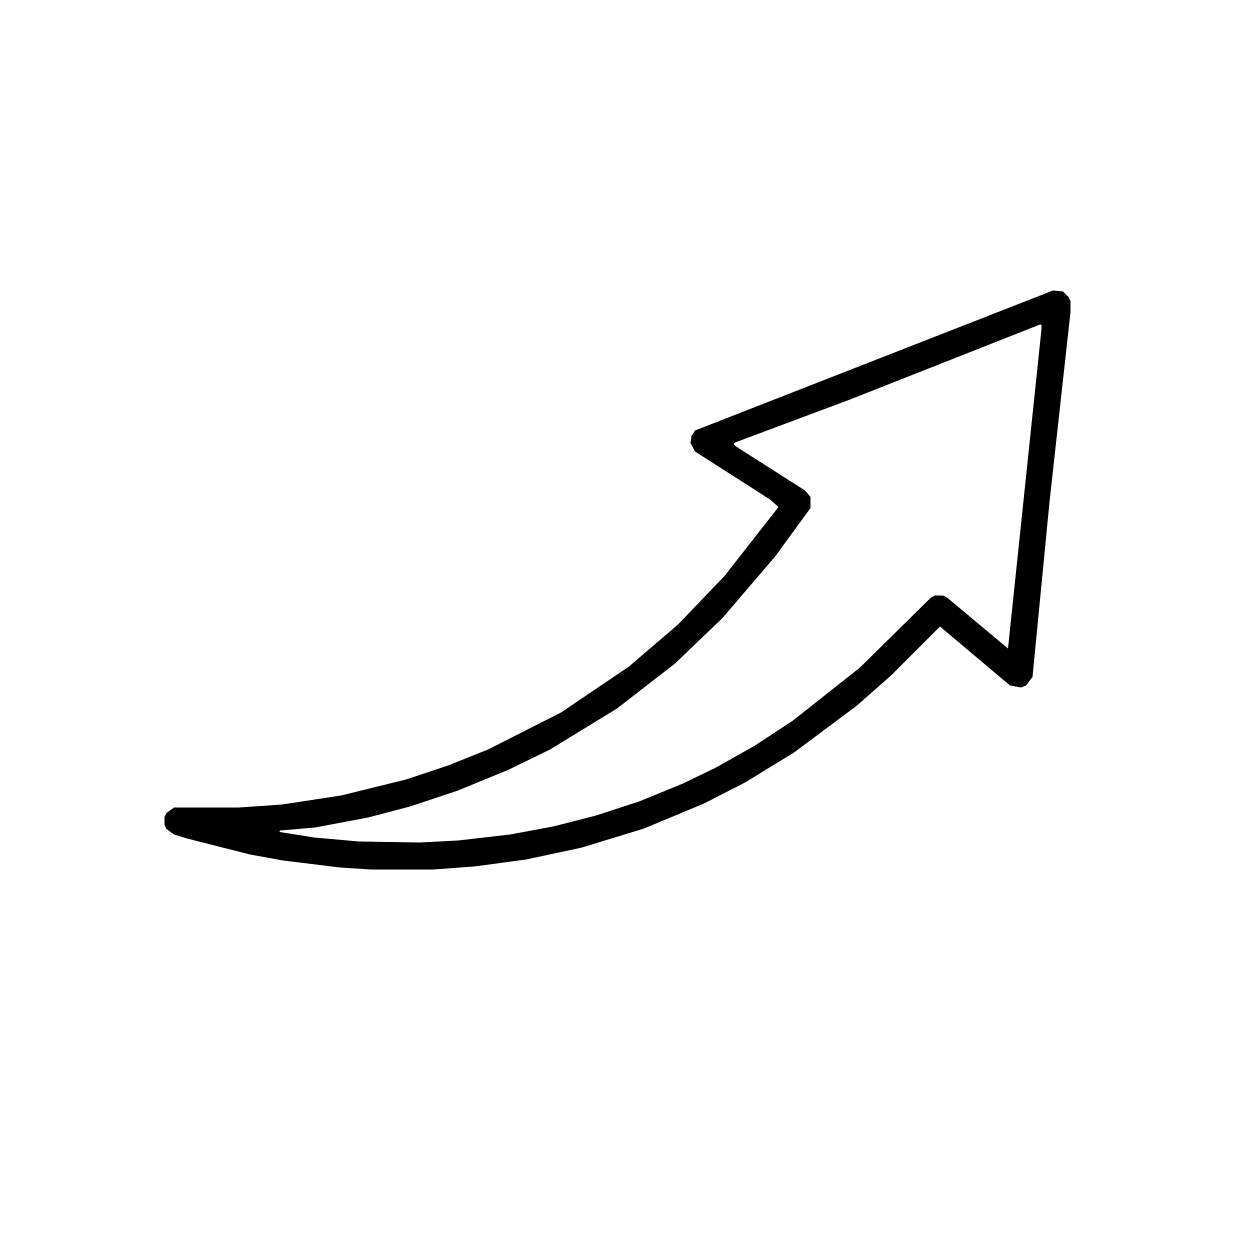

c77cf8abcefccf5434b4491917ece895.svg


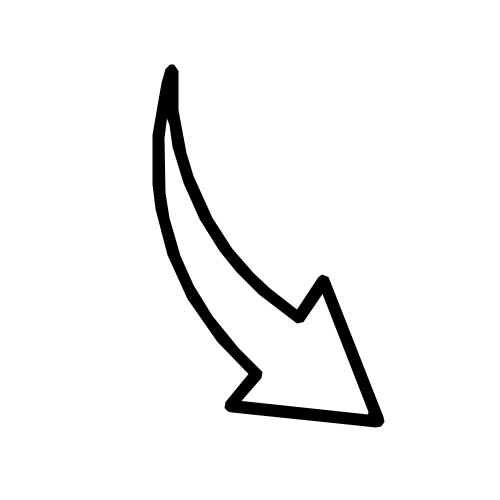

In [4]:
from IPython.display import SVG, display

for svg_path in sorted(HERE.glob('*.svg')):
    print(svg_path.name)
    display(SVG(filename=str(svg_path)))
